In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [2]:
df = pd.read_csv('/content/clean.csv')

In [3]:
df['rating'] = df['reviews'].apply(
    lambda x: float(re.search(r'\d\.\d', str(x)).group())
    if re.search(r'\d\.\d', str(x)) else None
)

df['review_count'] = df['reviews'].apply(
    lambda x: int(re.search(r'\((\d+)', str(x)).group(1))
    if re.search(r'\((\d+)', str(x)) else None
)

In [4]:
def extract_prices(text):
    nums = re.findall(r'\d+', str(text))
    return [int(n) for n in nums]

df['menu_prices'] = df['menu'].apply(extract_prices)
df['menu_len'] = df['menu_prices'].apply(len)
df['avg_price'] = df['menu_prices'].apply(lambda x: np.mean(x) if len(x) > 0 else None)

In [5]:
df[['parsed_name','rating','review_count','menu_len','avg_price']].head(10)

,parsed_name,rating,review_count,menu_len,avg_price
0,Алло! Пицца,4.6,136.0,483,389.828157
1,PIZZASUSHIWOK,4.6,990.0,826,353.559322
2,Якитория,4.8,308.0,417,359.314149
3,Сити Пицца,NaN,NaN,352,432.150568
4,Zotman Pizza,4.8,889.0,216,298.800926
5,A4 Pizza,NaN,NaN,127,296.102362
6,Пицца & Гирос,4.4,881.0,134,269.253731
7,Пицца Паоло,4.7,15.0,51,399.745098
8,Oreganos пицца-паста,4.5,154.0,126,354.761905
9,Osteria Mario,4.9,164.0,188,329.771277


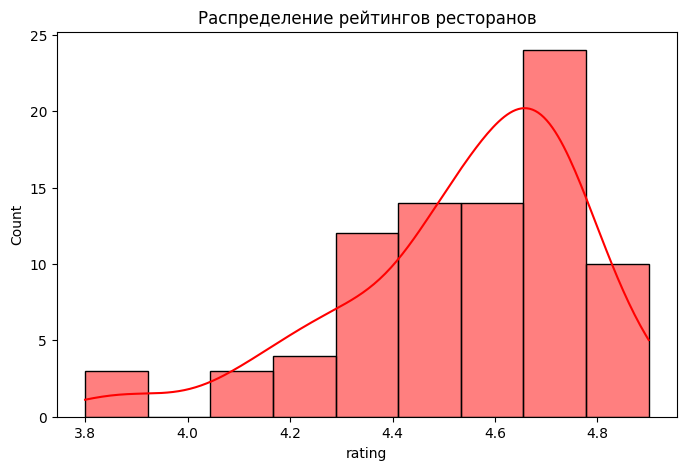

In [6]:
def extract_rating(text):
    match = re.search(r'\d\.\d', str(text))
    return float(match.group()) if match else None

def extract_count(text):
    match = re.search(r'\((\d+)', str(text))
    return int(match.group(1)) if match else None

df['rating'] = df['reviews'].apply(extract_rating)
df['review_count'] = df['reviews'].apply(extract_count)

plt.figure(figsize=(8,5))
sns.histplot(df['rating'].dropna(), kde=True, color='red')
plt.title('Распределение рейтингов ресторанов')
plt.show()

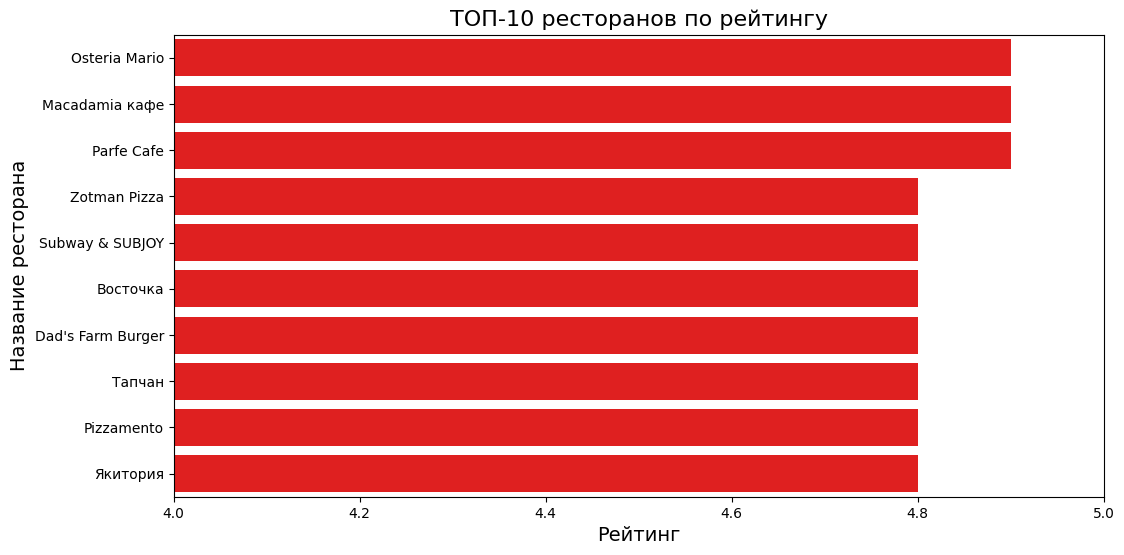

In [7]:
top_rating = df.dropna(subset=['rating']).sort_values('rating', ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(y=top_rating['parsed_name'], x=top_rating['rating'], color='red')
plt.xlim(4.0, 5)
plt.title('ТОП-10 ресторанов по рейтингу', fontsize=16)
plt.xlabel('Рейтинг', fontsize=14)
plt.ylabel('Название ресторана', fontsize=14)
plt.show()

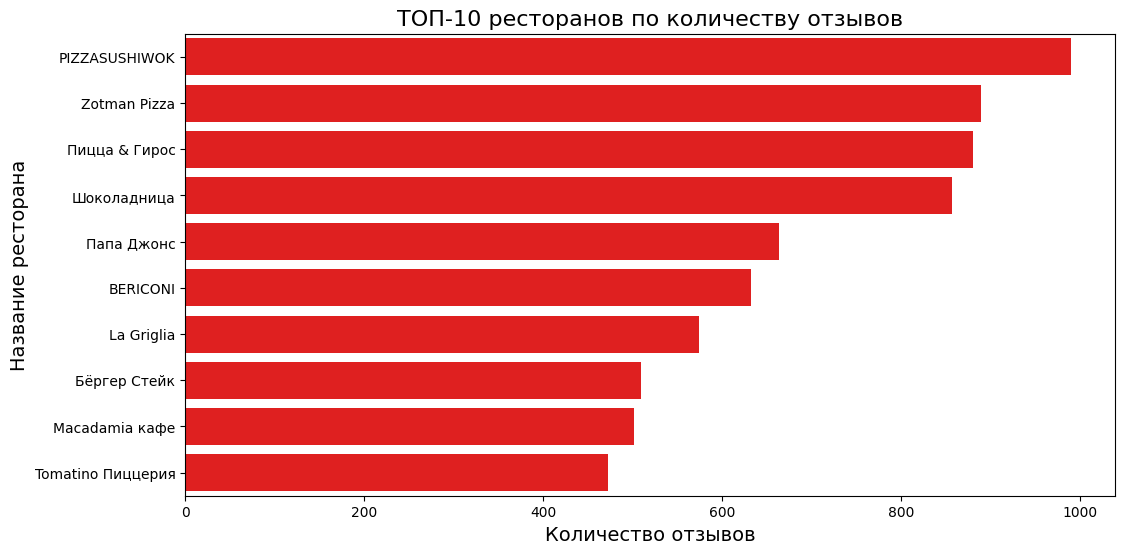

In [8]:
top_reviews = df.dropna(subset=['review_count']).sort_values('review_count', ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(y=top_reviews['parsed_name'], x=top_reviews['review_count'], color='red')
plt.title('ТОП-10 ресторанов по количеству отзывов', fontsize=16)
plt.xlabel('Количество отзывов', fontsize=14)
plt.ylabel('Название ресторана', fontsize=14)
plt.show()

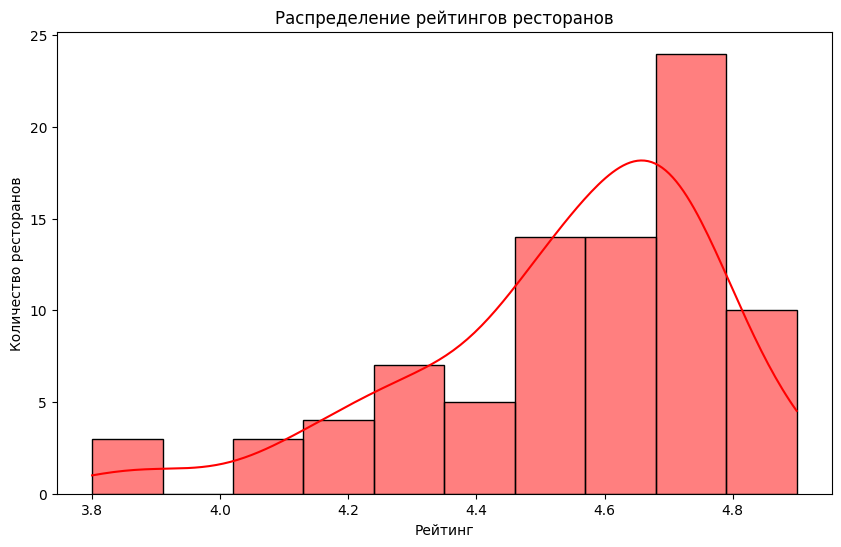

In [9]:
plt.figure(figsize=(10,6))
sns.histplot(df['rating'].dropna(), kde=True, bins=10, color='red')
plt.title('Распределение рейтингов ресторанов')
plt.xlabel('Рейтинг')
plt.ylabel('Количество ресторанов')
plt.show()

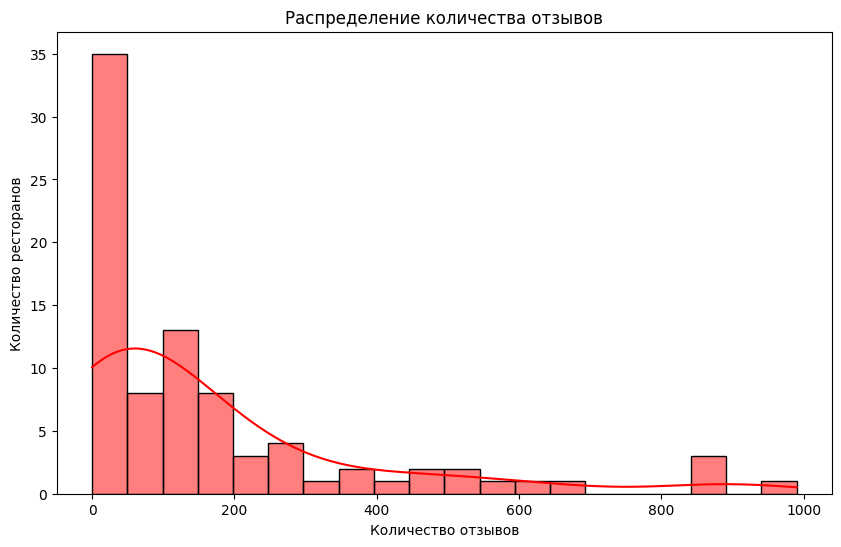

In [10]:
plt.figure(figsize=(10,6))
sns.histplot(df['review_count'].dropna(), kde=True, bins=20, color='red')
plt.title('Распределение количества отзывов')
plt.xlabel('Количество отзывов')
plt.ylabel('Количество ресторанов')
plt.show()

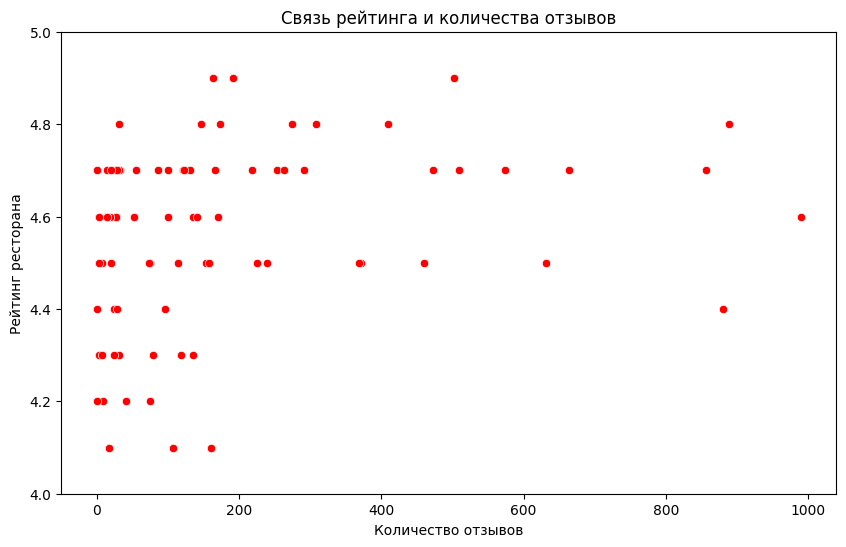

In [11]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=df['review_count'], y=df['rating'], color='red')
plt.title('Связь рейтинга и количества отзывов')
plt.xlabel('Количество отзывов')
plt.ylabel('Рейтинг ресторана')
plt.ylim(4.0,5)
plt.show()

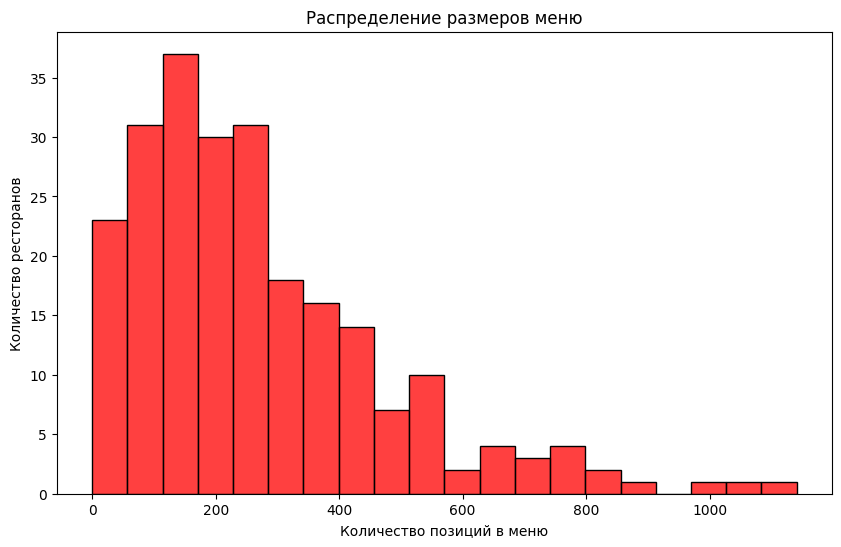

In [12]:
plt.figure(figsize=(10,6))
sns.histplot(df['menu_len'], bins=20, color='red')
plt.title('Распределение размеров меню')
plt.xlabel('Количество позиций в меню')
plt.ylabel('Количество ресторанов')
plt.show()

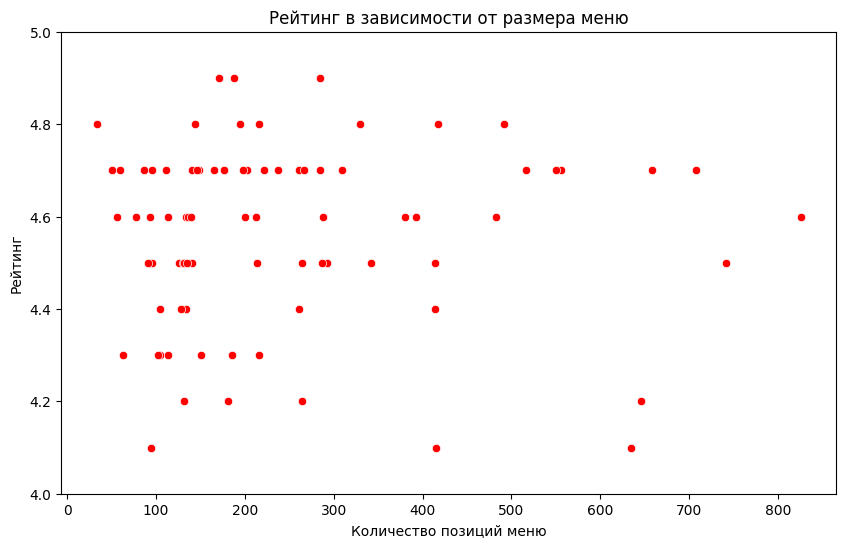

In [13]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=df['menu_len'], y=df['rating'], color='red')
plt.title('Рейтинг в зависимости от размера меню')
plt.xlabel('Количество позиций меню')
plt.ylabel('Рейтинг')
plt.ylim(4.0,5)
plt.show()

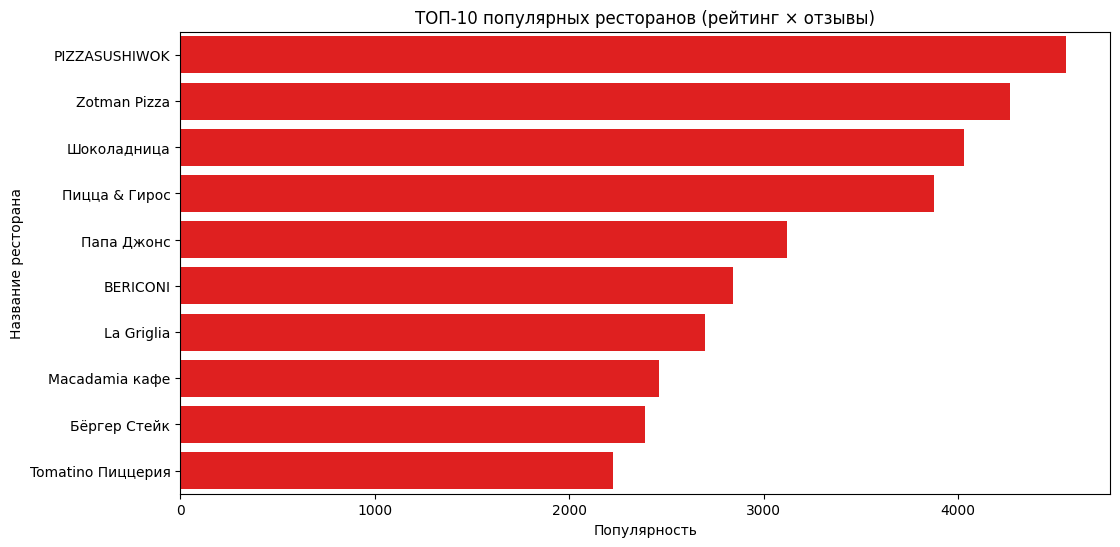

In [14]:
df['popularity'] = df['rating'] * df['review_count']

top_pop = df.dropna(subset=['popularity']).sort_values('popularity', ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(y=top_pop['parsed_name'], x=top_pop['popularity'], color='red')
plt.title('ТОП-10 популярных ресторанов (рейтинг × отзывы)')
plt.xlabel('Популярность')
plt.ylabel('Название ресторана')
plt.show()

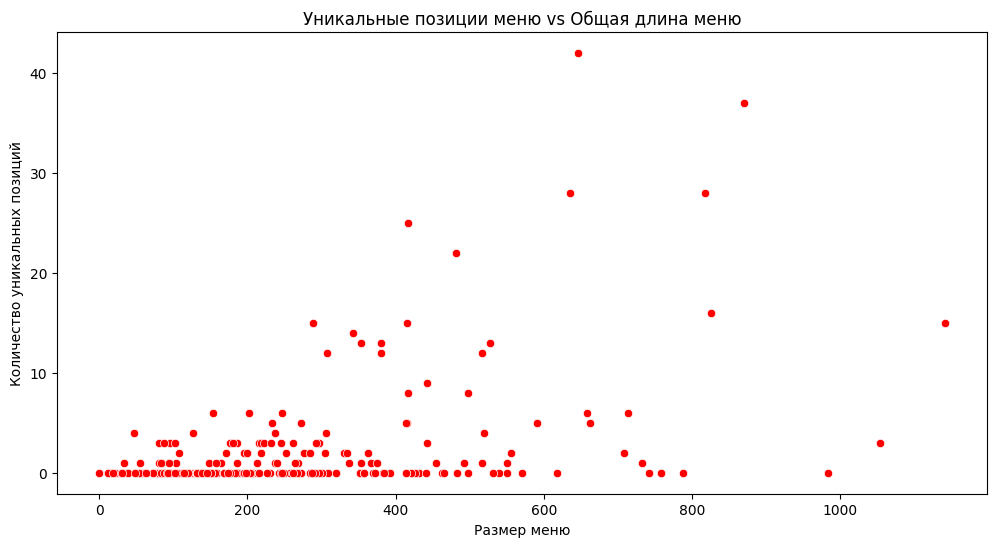

In [15]:
import collections

def count_unique(menu_list):
    all_items = []
    for lst in df['menu_prices']:
        all_items.extend(lst)
    counter = collections.Counter(all_items)
    return sum(1 for x in menu_list if counter[x] == 1)

df['unique_items'] = df['menu_prices'].apply(count_unique)

plt.figure(figsize=(12,6))
sns.scatterplot(x=df['menu_len'], y=df['unique_items'], color='red')
plt.title('Уникальные позиции меню vs Общая длина меню')
plt.xlabel('Размер меню')
plt.ylabel('Количество уникальных позиций')
plt.show()

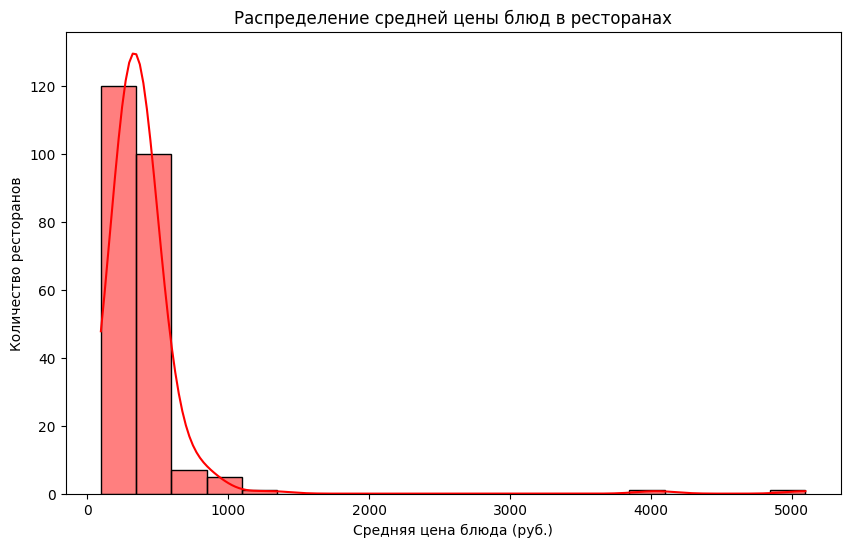

In [16]:
plt.figure(figsize=(10,6))
sns.histplot(df['avg_price'].dropna(), bins=20, kde=True, color='red')
plt.title('Распределение средней цены блюд в ресторанах')
plt.xlabel('Средняя цена блюда (руб.)')
plt.ylabel('Количество ресторанов')
plt.show()

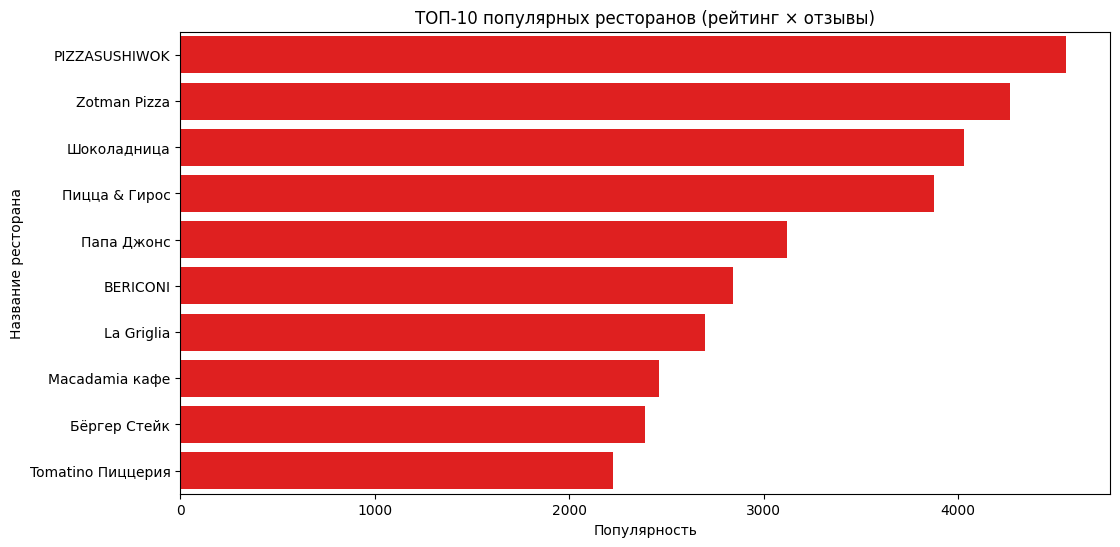

In [17]:
df['popularity'] = df['rating'] * df['review_count']

top_pop = df.dropna(subset=['popularity']).sort_values('popularity', ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(y=top_pop['parsed_name'], x=top_pop['popularity'], color='red')
plt.title('ТОП-10 популярных ресторанов (рейтинг × отзывы)')
plt.xlabel('Популярность')
plt.ylabel('Название ресторана')
plt.show()

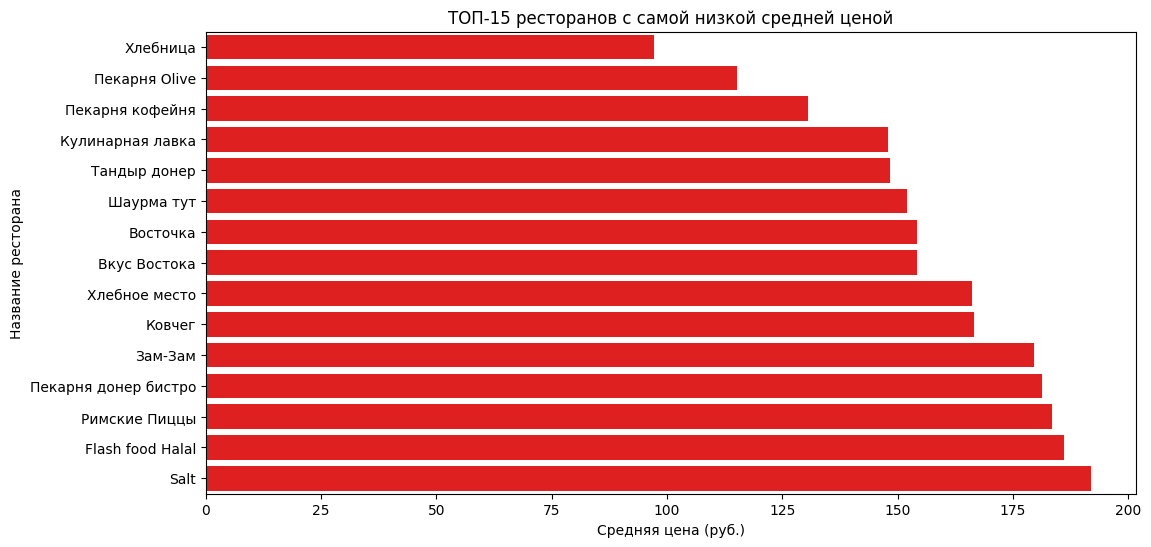

In [18]:
cheap = df.dropna(subset=['avg_price']).sort_values('avg_price').head(15)

plt.figure(figsize=(12,6))
sns.barplot(y=cheap['parsed_name'], x=cheap['avg_price'], color='red')
plt.title('ТОП-15 ресторанов с самой низкой средней ценой')
plt.xlabel('Средняя цена (руб.)')
plt.ylabel('Название ресторана')
plt.show()

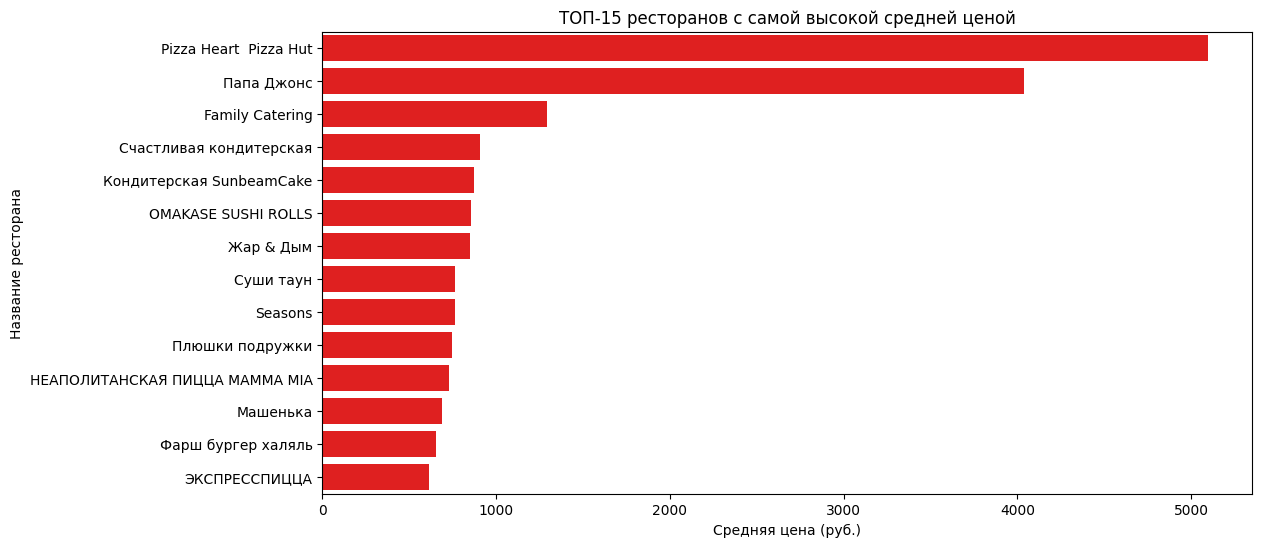

In [19]:
expensive = df.dropna(subset=['avg_price']).sort_values('avg_price', ascending=False).head(15)

plt.figure(figsize=(12,6))
sns.barplot(y=expensive['parsed_name'], x=expensive['avg_price'], color='red')
plt.title('ТОП-15 ресторанов с самой высокой средней ценой')
plt.xlabel('Средняя цена (руб.)')
plt.ylabel('Название ресторана')
plt.show()

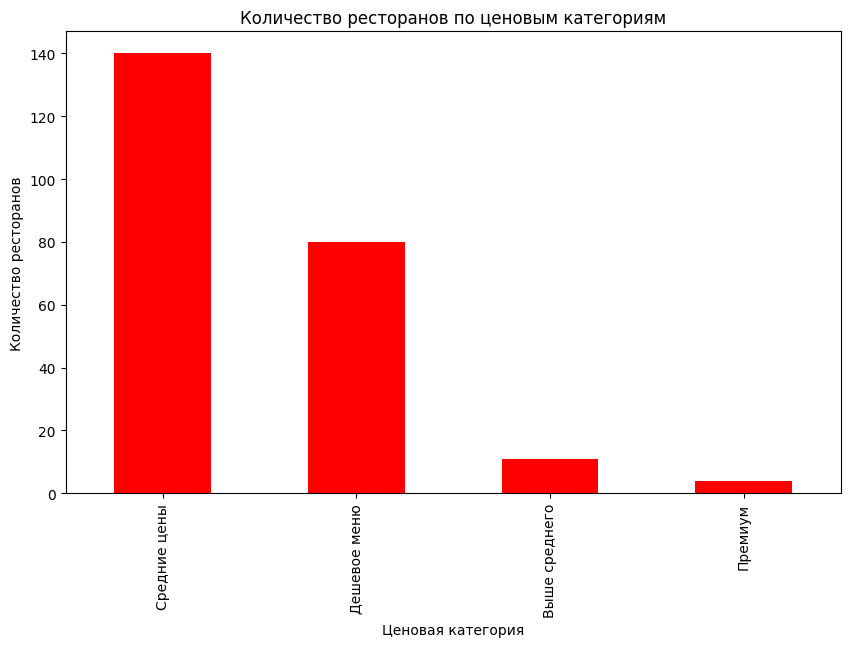

In [20]:
df['price_group'] = pd.cut(
    df['avg_price'],
    bins=[0,300,600,900,10000],
    labels=['Дешевое меню','Средние цены','Выше среднего','Премиум']
)

plt.figure(figsize=(10,6))
df['price_group'].value_counts().plot(kind='bar', color='red')
plt.title('Количество ресторанов по ценовым категориям')
plt.xlabel('Ценовая категория')
plt.ylabel('Количество ресторанов')
plt.show()

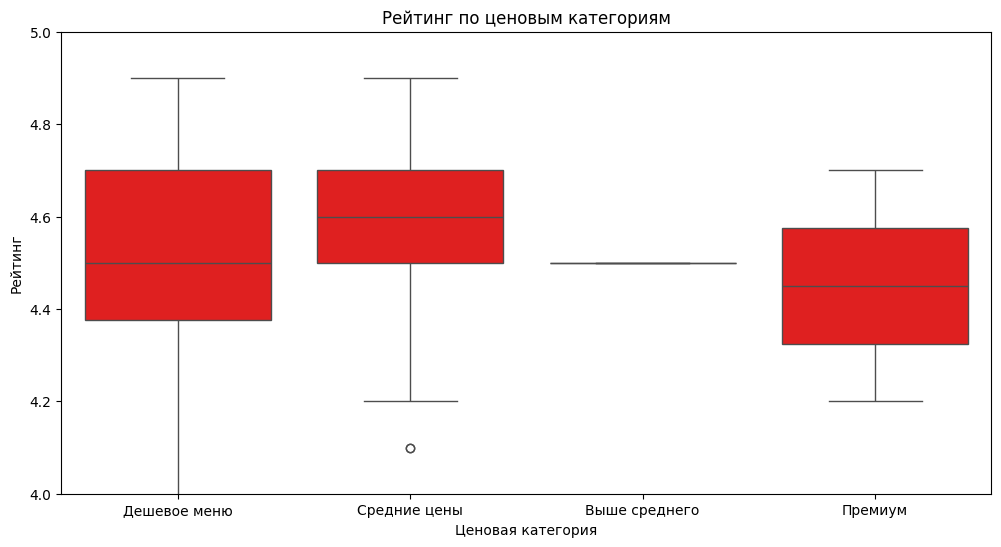

In [21]:
plt.figure(figsize=(12,6))
sns.boxplot(x='price_group', y='rating', data=df, color='red')
plt.title('Рейтинг по ценовым категориям')
plt.xlabel('Ценовая категория')
plt.ylabel('Рейтинг')
plt.ylim(4.0,5)
plt.show()